In [1]:
import numpy as np
import pandas as pd 
import pandas as pad
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("job_salary.csv")
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


In [3]:
print(df.shape)
print(df.columns)


(250000, 10)
Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='object')


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [5]:
df.columns=df.columns.str.strip().str.lower().str.replace(" ","_")


In [6]:
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


### Salary per experience


In [7]:
df['salary_per_exp'] = df['salary'] / (df['experience_years'] + 1)
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,salary_per_exp
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413,9946.636364
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764,15627.333333
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123,7795.947368
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123,9456.150000
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069,10316.812500
...,...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791,7099.500000
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593,7361.571429
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988,37994.000000
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467,90467.000000


In [8]:
df['exp_level'] = pd.cut(df['experience_years'],
                         bins=[0,2,5,10,20],
                         labels=['fresher','junior','mid','senior'])

df            

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,salary_per_exp,exp_level
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413,9946.636364,mid
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764,15627.333333,junior
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123,7795.947368,senior
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123,9456.150000,senior
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069,10316.812500,senior
...,...,...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791,7099.500000,senior
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593,7361.571429,senior
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988,37994.000000,fresher
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467,90467.000000,NaN


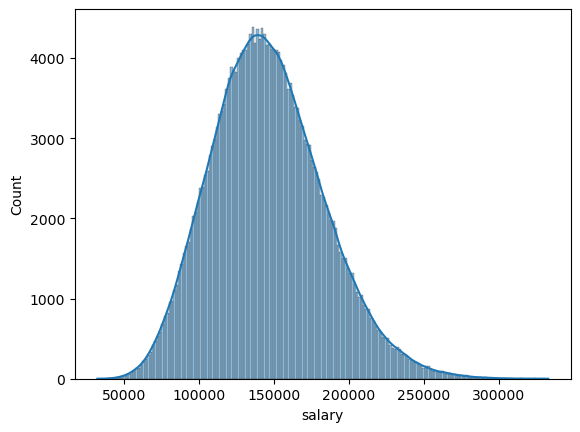

In [9]:
sns.histplot(df['salary'],kde=True)
plt.show()

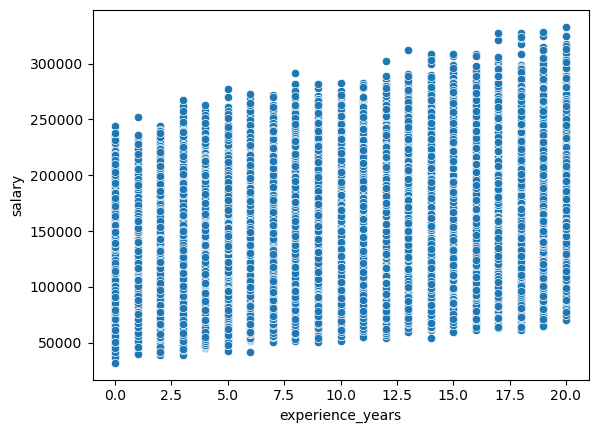

In [10]:
sns.scatterplot(x='experience_years',y='salary',data=df)
plt.show()

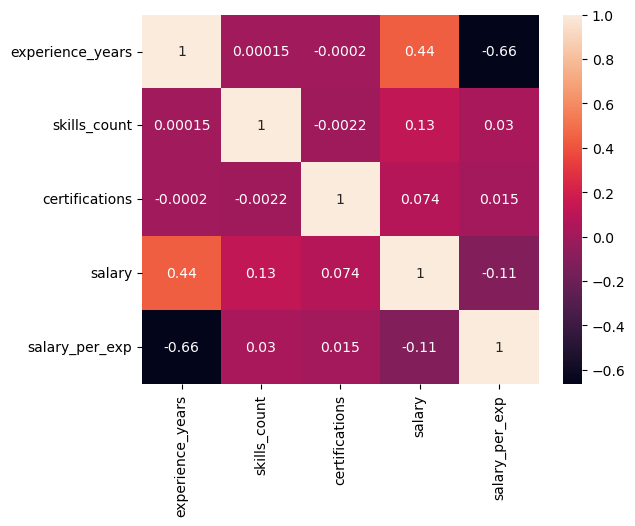

In [11]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

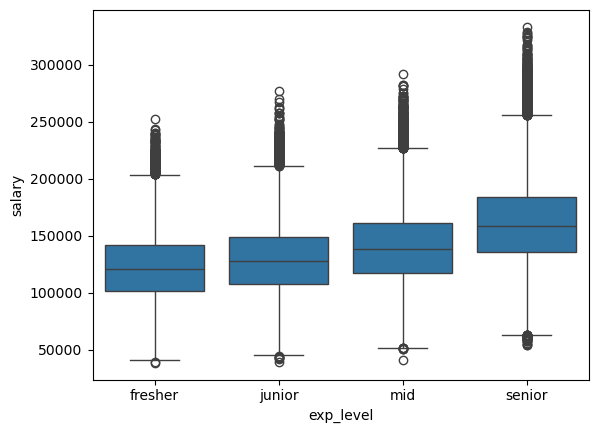

In [12]:
sns.boxplot(x='exp_level',y='salary',data=df)
plt.show()

In [13]:
top_jobs = df.groupby('job_title')['salary'].mean().sort_values(ascending=False)
print(top_jobs.head(10))

job_title
AI Engineer                  173498.480640
Machine Learning Engineer    163022.504570
Product Manager              157594.932029
Cloud Engineer               152102.535290
DevOps Engineer              149959.266791
Cybersecurity Analyst        148697.695548
Data Scientist               147258.214409
Software Engineer            141739.521460
Backend Developer            139202.768663
Frontend Developer           132653.842485
Name: salary, dtype: float64


In [14]:
avg_sal=df.groupby('job_title')['salary'].transform('mean')
df['salary_gap']=df['salary']- avg_sal
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,salary_per_exp,exp_level,salary_gap
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413,9946.636364,mid,-64085.480640
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764,15627.333333,junior,-26127.696603
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123,7795.947368,senior,15469.157515
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123,9456.150000,senior,66571.768646
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069,10316.812500,senior,7474.067971
...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791,7099.500000,senior,-13948.521460
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593,7361.571429,senior,21939.157515
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988,37994.000000,fresher,-46563.231354
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467,90467.000000,NaN,-56791.214409


In [15]:
underpaid = df[df['salary_gap'] < 0]
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,salary_per_exp,exp_level,salary_gap
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413,9946.636364,mid,-64085.480640
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764,15627.333333,junior,-26127.696603
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123,7795.947368,senior,15469.157515
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123,9456.150000,senior,66571.768646
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069,10316.812500,senior,7474.067971
...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791,7099.500000,senior,-13948.521460
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593,7361.571429,senior,21939.157515
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988,37994.000000,fresher,-46563.231354
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467,90467.000000,NaN,-56791.214409


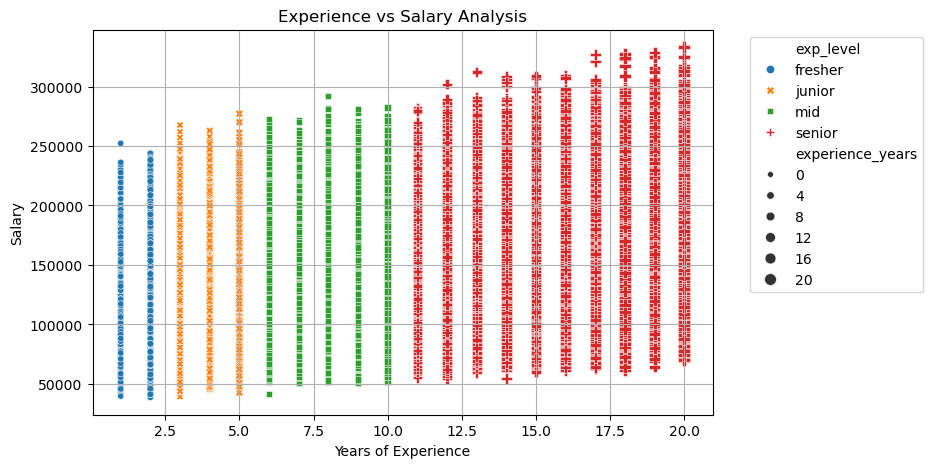

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='experience_years',
    y='salary',
    data=df,
    hue='exp_level',     
    size='experience_years',   
    style='exp_level'    
)

plt.title("Experience vs Salary Analysis")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.legend(title="Experience Level")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True)
plt.show()

C:\Users\vanshitpatel\AppData\Local\Temp\ipykernel_16012\533649586.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_salary = df.groupby('exp_level')['salary'].mean()


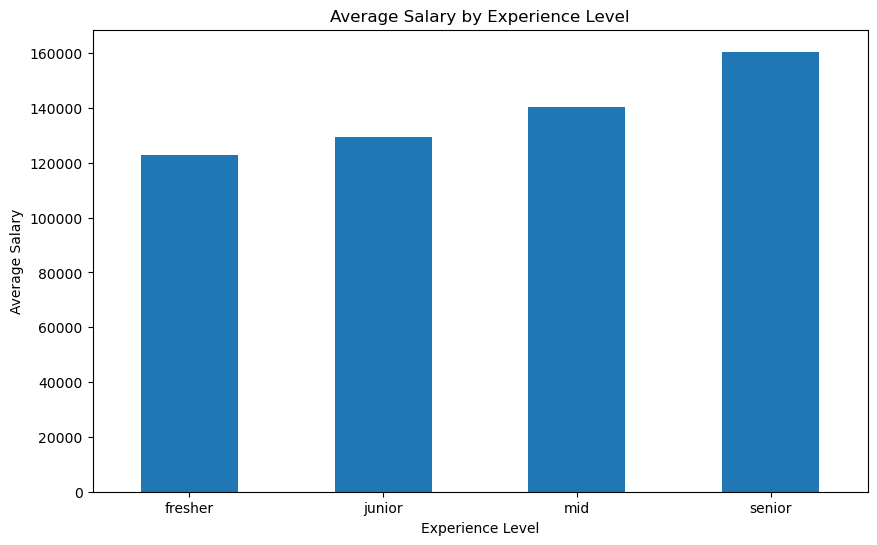

In [17]:
plt.figure(figsize=(10,6))

avg_salary = df.groupby('exp_level')['salary'].mean()

avg_salary.plot(kind='bar')

plt.title("Average Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Average Salary")

plt.xticks(rotation=0)
plt.show()

C:\Users\vanshitpatel\AppData\Local\Temp\ipykernel_16012\2932507910.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_salary = df.groupby('exp_level')['salary'].mean()


Text(0.5, 1.0, 'Top 10 Highest Paying Jobs')

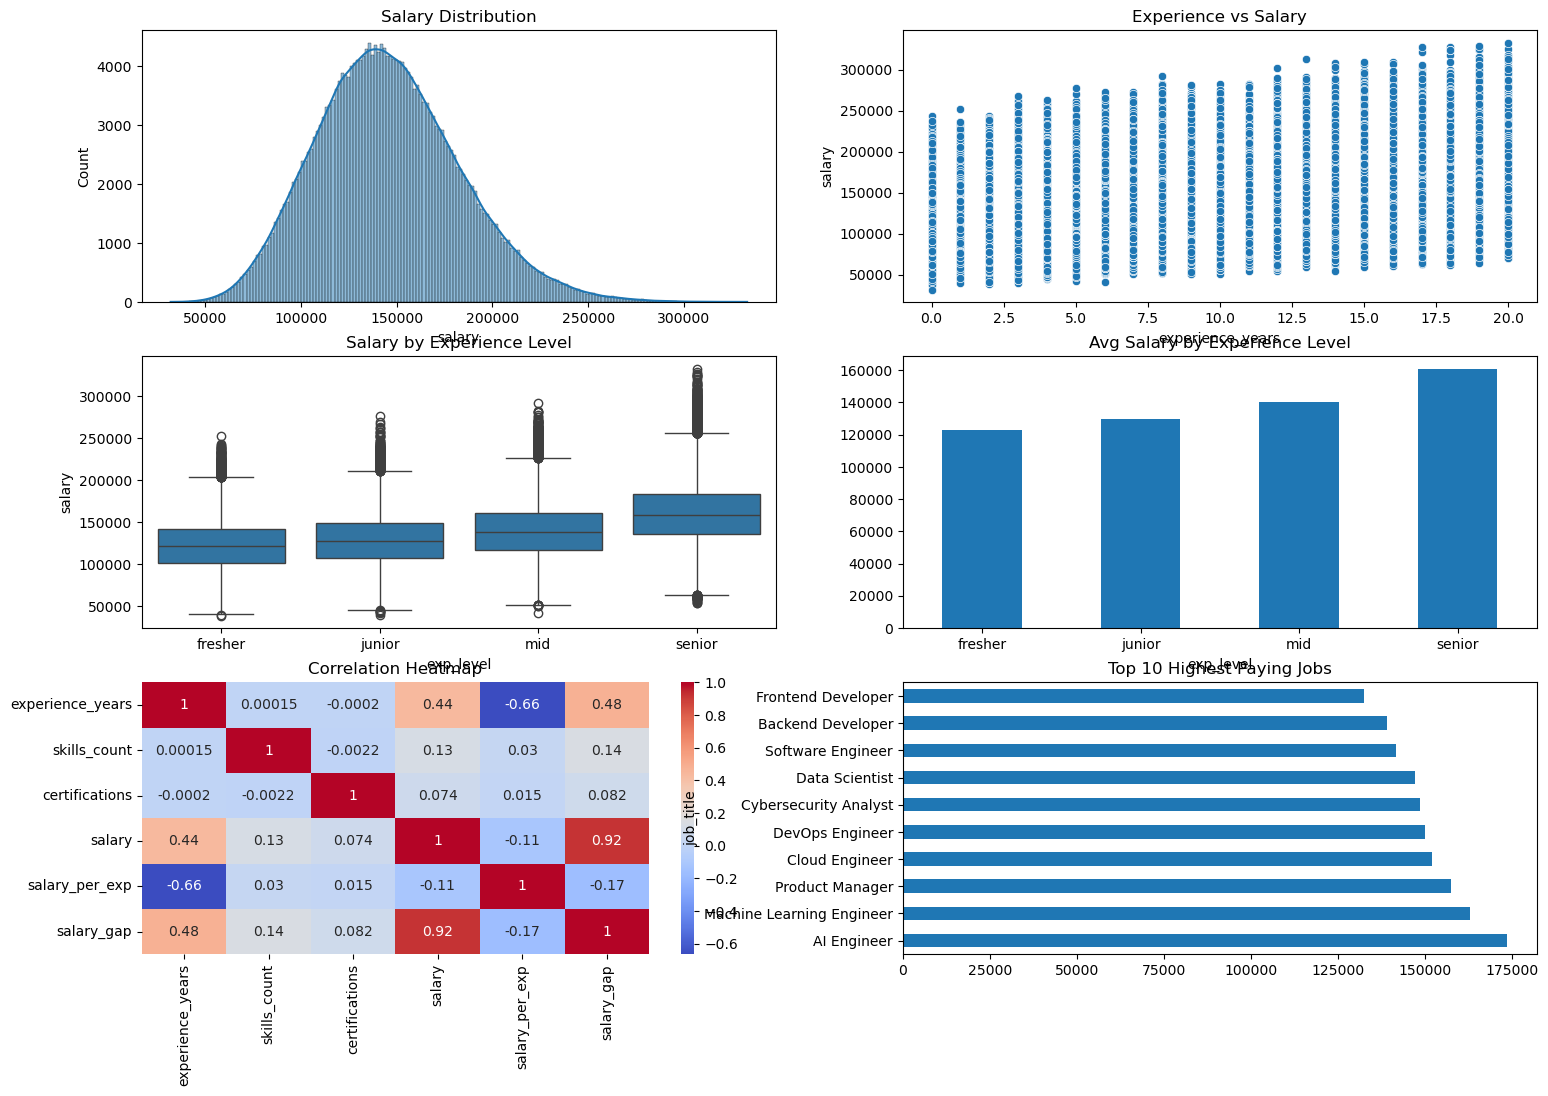

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18,12))

plt.subplot(3,2,1)
sns.histplot(df['salary'], kde=True)
plt.title("Salary Distribution")

plt.subplot(3,2,2)
sns.scatterplot(x='experience_years', y='salary', data=df)
plt.title("Experience vs Salary")

plt.subplot(3,2,3)
sns.boxplot(x='exp_level', y='salary', data=df)
plt.title("Salary by Experience Level")

plt.subplot(3,2,4)
avg_salary = df.groupby('exp_level')['salary'].mean()
avg_salary.plot(kind='bar')
plt.title("Avg Salary by Experience Level")
plt.xticks(rotation=0)

plt.subplot(3,2,5)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")

plt.subplot(3,2,6)
top_jobs = df.groupby('job_title')['salary'].mean().sort_values(ascending=False).head(10)
top_jobs.plot(kind='barh')
plt.title("Top 10 Highest Paying Jobs")



C:\Users\vanshitpatel\AppData\Local\Temp\ipykernel_16012\1225720330.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='exp_level', y='salary', data=df, palette='coolwarm', linewidth=2)
C:\Users\vanshitpatel\AppData\Local\Temp\ipykernel_16012\1225720330.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('exp_level')['salary'].mean().plot(kind='bar', color='orange')
C:\Users\vanshitpatel\AppData\Local\Temp\ipykernel_16012\1225720330.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplo

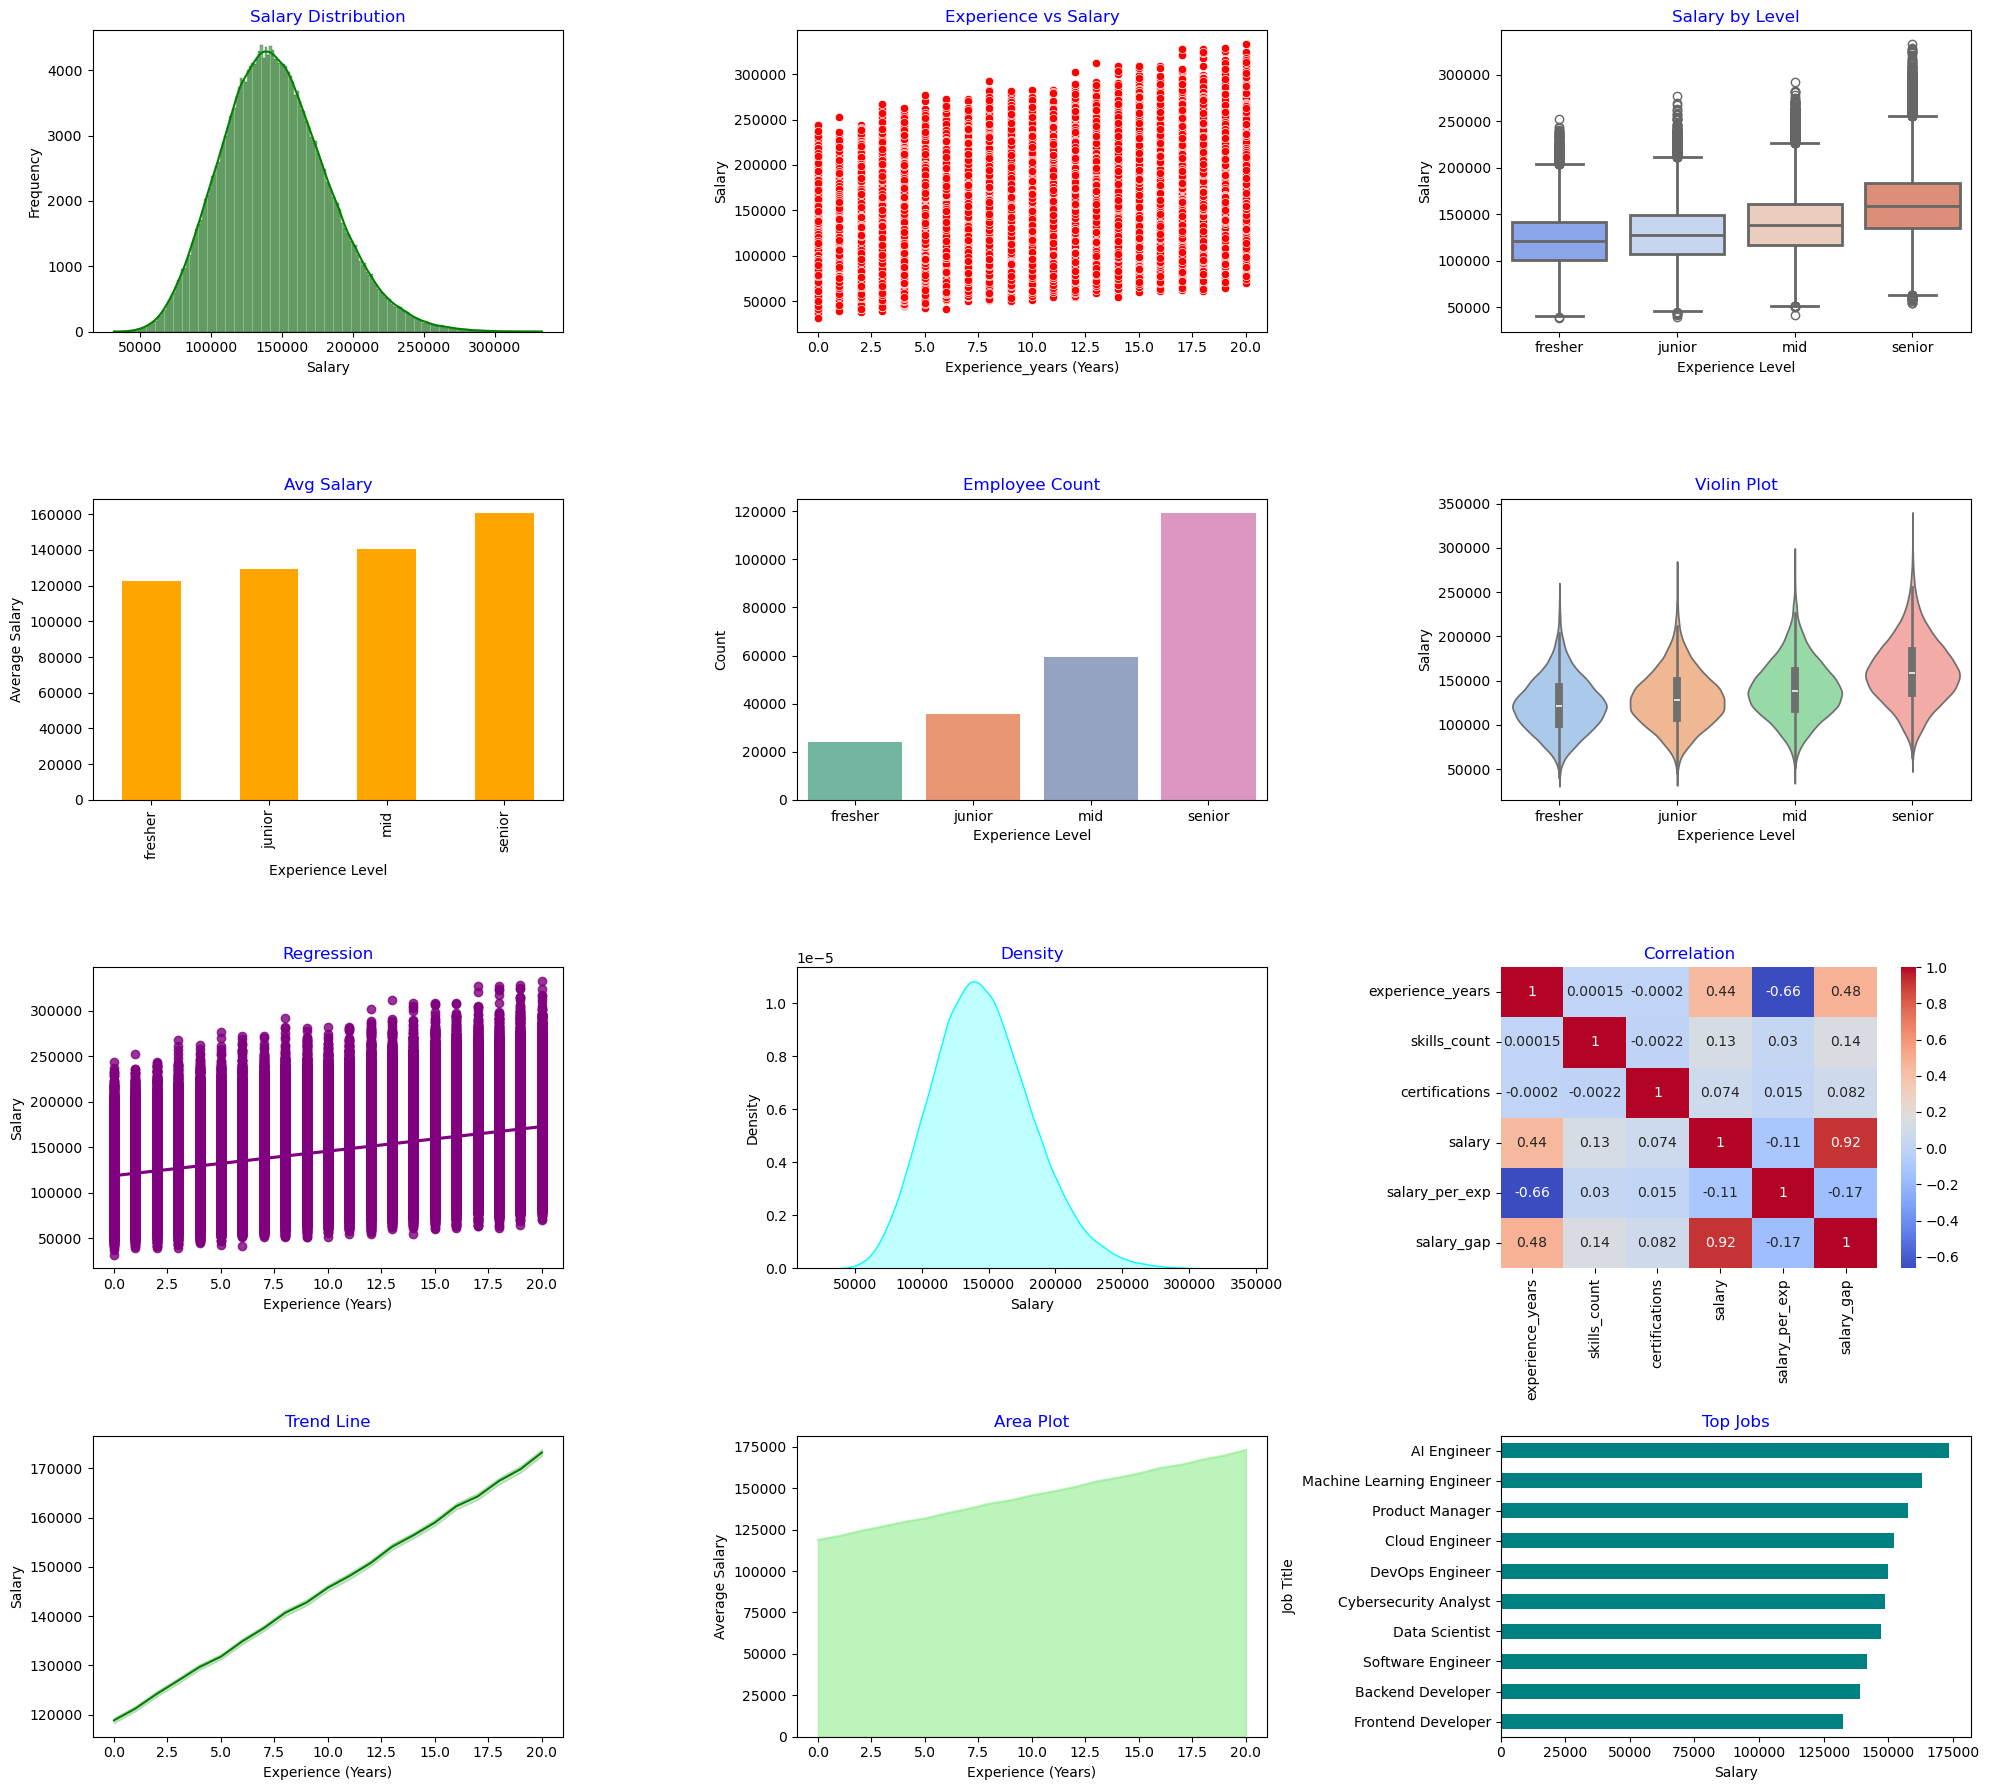

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,18))

# 1. Histogram
plt.subplot(4,3,1)
sns.histplot(df['salary'], kde=True, color='green')
plt.title("Salary Distribution", color='blue')
plt.xlabel("Salary")
plt.ylabel("Frequency")

# 2. Scatter
plt.subplot(4,3,2)
sns.scatterplot(x='experience_years', y='salary', data=df, color='red')
plt.title("Experience vs Salary", color='blue')
plt.xlabel("Experience_years (Years)")
plt.ylabel("Salary")

# 3. Boxplot
plt.subplot(4,3,3)
sns.boxplot(x='exp_level', y='salary', data=df, palette='coolwarm', linewidth=2)
plt.title("Salary by Level", color='blue')
plt.xlabel("Experience Level")
plt.ylabel("Salary")

# 4. Bar Plot
plt.subplot(4,3,4)
df.groupby('exp_level')['salary'].mean().plot(kind='bar', color='orange')
plt.title("Avg Salary", color='blue')
plt.xlabel("Experience Level")
plt.ylabel("Average Salary")

# 5. Count Plot
plt.subplot(4,3,5)
sns.countplot(x='exp_level', data=df, palette='Set2')
plt.title("Employee Count", color='blue')
plt.xlabel("Experience Level")
plt.ylabel("Count")

# 6. Violin Plot
plt.subplot(4,3,6)
sns.violinplot(x='exp_level', y='salary', data=df, palette='pastel')
plt.title("Violin Plot", color='blue')
plt.xlabel("Experience Level")
plt.ylabel("Salary")

# 7. Regression Plot
plt.subplot(4,3,7)
sns.regplot(x='experience_years', y='salary', data=df, color='purple')
plt.title("Regression", color='blue')
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")

# 8. KDE Plot
plt.subplot(4,3,8)
sns.kdeplot(df['salary'], fill=True, color='cyan')
plt.title("Density", color='blue')
plt.xlabel("Salary")
plt.ylabel("Density")

# 9. Heatmap
plt.subplot(4,3,9)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation", color='blue')

# 10. Line Plot
plt.subplot(4,3,10)
sns.lineplot(x='experience_years', y='salary', data=df, color='green')
plt.title("Trend Line", color='blue')
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")

# 11. Area Plot
plt.subplot(4,3,11)
df.groupby('experience_years')['salary'].mean().plot(kind='area', color='lightgreen', alpha=0.6)
plt.title("Area Plot", color='blue')
plt.xlabel("Experience (Years)")
plt.ylabel("Average Salary")

# 12. Horizontal Bar
plt.subplot(4,3,12)
df.groupby('job_title')['salary'].mean().sort_values().tail(10).plot(kind='barh', color='teal')
plt.title("Top Jobs", color='blue')
plt.xlabel("Salary")
plt.ylabel("Job Title")

plt.tight_layout()
plt.show()